# Course 3 · Week 1 — Solution: K-means and Anomaly Detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Three Gaussian blobs in 2D — but we won't tell K-means the labels.
np.random.seed(2)
m_per_cluster = 40
centers_true = np.array([[-2, -2], [2, -2], [0, 2.5]])
X_clusters = np.vstack([np.random.randn(m_per_cluster, 2) * 0.6 + c for c in centers_true])
print(f"X shape: {X_clusters.shape}")

K = 3


X shape: (120, 2)


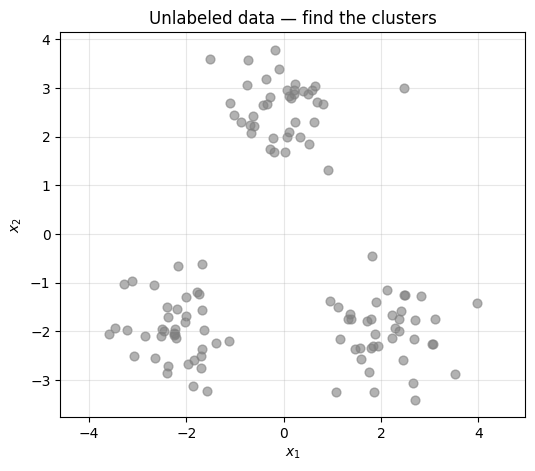

In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(X_clusters[:, 0], X_clusters[:, 1], color="gray", s=40, alpha=0.6)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Unlabeled data — find the clusters")
plt.grid(alpha=0.3); plt.axis("equal")
plt.show()


## Quick recap — K-means

The simplest unsupervised algorithm. You pick `K` (the number of clusters you want), and the algorithm:

1. **Assign** each point to the nearest centroid
2. **Update** each centroid to be the mean of its assigned points
3. Repeat until nothing changes

Two clean facts:
- The cost `J` (mean squared distance from each point to its centroid) **never increases** between iterations. Each step solves one half of the optimization while holding the other fixed.
- The result depends on initialization. Bad starts → bad local minima. Standard trick: run K-means with several random starts, pick the best.


**Assign:** for every point, compute distance to every centroid; argmin gives the cluster index. The neat trick is `X[:, None, :] - centroids[None, :, :]` which broadcasts to a (m, K, n) tensor of differences — then take the L2 norm along axis=2 to collapse to (m, K).

In [3]:
def assign_clusters(X, centroids):
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    return dists.argmin(axis=1)

X_test = np.array([[0, 0], [1, 1], [10, 10]])
centroids_test = np.array([[0.5, 0.5], [9, 9]])
out = assign_clusters(X_test, centroids_test)
assert (out == np.array([0, 0, 1])).all()
print("✓ assign_clusters() works")


✓ assign_clusters() works


**Update:** loop over clusters, take the mean of assigned points. Edge case: if a cluster lost all its points, leave its centroid unchanged.

In [4]:
def update_centroids(X, c, K):
    new_centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        if (c == k).any():
            new_centroids[k] = X[c == k].mean(axis=0)
    return new_centroids

c_test = np.array([0, 0, 1])
new_c = update_centroids(X_test, c_test, 2)
assert abs(new_c[0, 0] - 0.5) < 1e-9
print("✓ update_centroids() works")


✓ update_centroids() works


**Distortion:** J = mean of ||x_i - centroid[c_i]||². The numpy `centroids[c]` indexing builds a (m, n) array of "the centroid for each point" in one line.

In [5]:
def distortion(X, c, centroids):
    return float(np.mean(np.linalg.norm(X - centroids[c], axis=1) ** 2))

X_perfect = np.array([[0, 0], [10, 10]])
assert distortion(X_perfect, np.array([0, 1]), np.array([[0, 0], [10, 10]])) == 0
print("✓ distortion() works")


✓ distortion() works


**The loop:** assign → update → repeat. K-means converges fast on well-separated blobs (4 iterations for our data). The plot of J should show monotonic decrease and convergence.

Initial centroids:
[[ 2.22828318 -2.13028116]
 [ 0.21548     2.87333225]
 [ 0.57646917  2.95502221]]
step  0: J = 4.1837
step  1: J = 3.8914
step  2: J = 3.8909
step  3: J = 3.8909
step  4: J = 3.8909
step 19: J = 3.8909


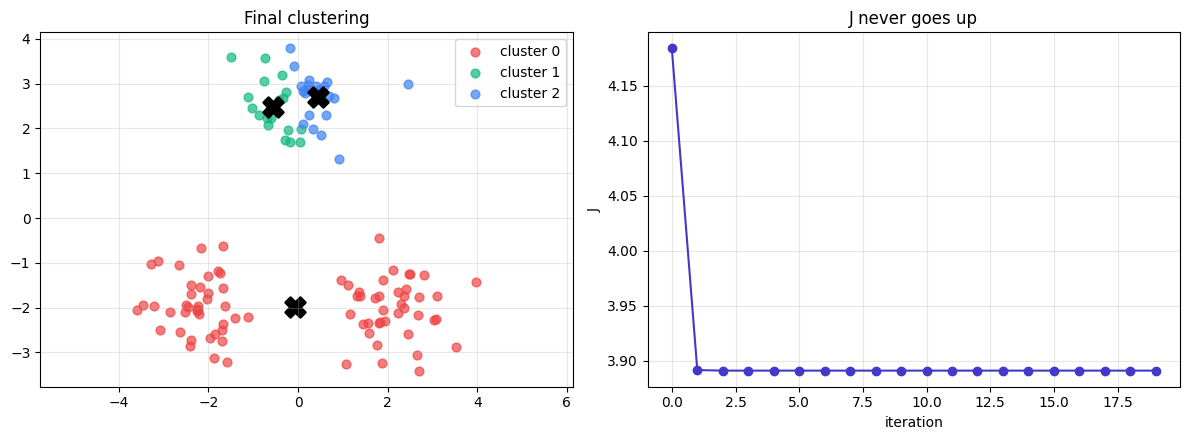

In [6]:
np.random.seed(0)
init_idx = np.random.choice(len(X_clusters), K, replace=False)
centroids = X_clusters[init_idx].copy()
print(f"Initial centroids:\n{centroids}")

J_history = []
for step in range(20):
    c = assign_clusters(X_clusters, centroids)
    centroids = update_centroids(X_clusters, c, K)
    J = distortion(X_clusters, c, centroids)
    J_history.append(J)
    if step < 5 or step == 19:
        print(f"step {step:2d}: J = {J:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#ef4444", "#10b981", "#3b82f6"]
for k in range(K):
    axes[0].scatter(X_clusters[c == k, 0], X_clusters[c == k, 1], color=colors[k], s=40, alpha=0.7, label=f"cluster {k}")
axes[0].scatter(centroids[:, 0], centroids[:, 1], color="black", marker="X", s=200, lw=2)
axes[0].set_title("Final clustering"); axes[0].legend(); axes[0].axis("equal"); axes[0].grid(alpha=0.3)

axes[1].plot(J_history, "o-", color="#4338ca")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("J")
axes[1].set_title("J never goes up"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Anomaly detection

X_anom shape: (83, 2), true anomalies: 3


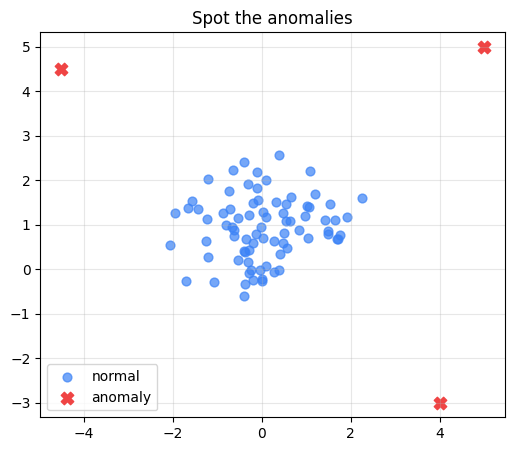

In [7]:
# Anomaly detection setup: 80 "normal" points + 3 obvious anomalies
np.random.seed(7)
m_norm = 80
X_norm = np.random.randn(m_norm, 2) * np.array([1.0, 0.7]) + np.array([0.0, 1.0])
anomalies = np.array([[5.0, 5.0], [-4.5, 4.5], [4.0, -3.0]])
X_anom = np.vstack([X_norm, anomalies])
y_anom = np.array([0]*m_norm + [1]*3)
print(f"X_anom shape: {X_anom.shape}, true anomalies: {int(y_anom.sum())}")

plt.figure(figsize=(6, 5))
plt.scatter(X_anom[y_anom == 0, 0], X_anom[y_anom == 0, 1], color="#3b82f6", s=40, label="normal", alpha=0.7)
plt.scatter(X_anom[y_anom == 1, 0], X_anom[y_anom == 1, 1], color="#ef4444", s=80, marker="X", label="anomaly")
plt.legend(); plt.grid(alpha=0.3); plt.axis("equal"); plt.title("Spot the anomalies")
plt.show()


## Quick recap — anomaly detection

If you can model what "normal" looks like, you can flag anything that doesn't look normal.

Standard approach: fit an independent Gaussian to each feature, multiply the per-feature probabilities to get a joint probability, threshold at `eps`. Below `eps` → anomaly.

This works when normal data clusters in some bounded region and anomalies are far outside. It fails when "normal" is multi-modal (multiple clusters) or when features are strongly correlated. For those cases you'd use multivariate Gaussian or other density models.


**Fit:** mean and variance per feature. Numpy's `axis=0` makes this one line each.

In [8]:
def fit_gaussian(X):
    mu = X.mean(axis=0)
    sigma2 = X.var(axis=0)
    return mu, sigma2

def p_gaussian(X, mu, sigma2):
    coef = 1 / np.sqrt(2 * np.pi * sigma2)
    return np.prod(coef * np.exp(-(X - mu)**2 / (2 * sigma2)), axis=1)

mu, sigma2 = fit_gaussian(X_norm)
print(f"mu     = {np.round(mu, 3)}")
print(f"sigma² = {np.round(sigma2, 3)}")

p = p_gaussian(X_anom, mu, sigma2)
print(f"\nProbabilities — first 5: {np.round(p[:5], 4)}")
print(f"Last 3 (the anomalies): {np.round(p[-3:], 6)}")
print("✓ Gaussian fit works")


mu     = [0.038 0.933]
sigma² = [0.893 0.504]

Probabilities — first 5: [0.048  0.2099 0.1611 0.0621 0.1095]
Last 3 (the anomalies): [0. 0. 0.]
✓ Gaussian fit works


**Threshold:** anomalies have probability orders of magnitude smaller than normal points (because the joint Gaussian decays exponentially in distance from the mean). On our data, normal points have probabilities in 0.05–0.30; anomalies are essentially 0. Almost any threshold between 1e-3 and 1e-10 works.

In [9]:
# Pick a threshold and flag anomalies
eps = 1e-5
flagged = p < eps

# Confusion-matrix-ish report
true_positives  = int(((flagged == 1) & (y_anom == 1)).sum())
false_positives = int(((flagged == 1) & (y_anom == 0)).sum())
false_negatives = int(((flagged == 0) & (y_anom == 1)).sum())
print(f"With eps = {eps}:")
print(f"  True positives  (caught real anomalies): {true_positives} / 3")
print(f"  False positives (normal flagged):        {false_positives}")
print(f"  False negatives (missed anomalies):      {false_negatives}")


With eps = 1e-05:
  True positives  (caught real anomalies): 3 / 3
  False positives (normal flagged):        0
  False negatives (missed anomalies):      0


## ⭐ Stretch — precision-recall trade-off\n\nVarying eps trades **precision** (of flagged things, how many were actually anomalies) for **recall** (of actual anomalies, how many did we catch). Tighter eps → high precision, lower recall. Looser eps → high recall, lower precision.\n\nThe right operating point depends on your application. Fraud detection: usually high recall (catching the bad stuff matters more than occasional false alarms). Email triage: usually high precision (false-flagging your boss's emails is expensive).

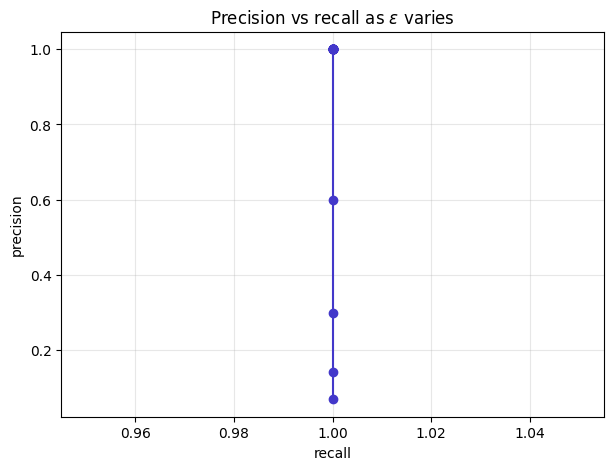

eps=1e-08: precision=1.000, recall=1.000
eps=1e-05: precision=1.000, recall=1.000
eps=0.001: precision=1.000, recall=1.000


In [10]:
def precision_recall(p, y, eps):
    flagged = p < eps
    tp = int(((flagged == 1) & (y == 1)).sum())
    fp = int(((flagged == 1) & (y == 0)).sum())
    fn = int(((flagged == 0) & (y == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

eps_grid = np.logspace(-10, -1, 30)
precs, recs = [], []
for eps in eps_grid:
    p_, r_ = precision_recall(p, y_anom, eps)
    precs.append(p_); recs.append(r_)

plt.figure(figsize=(7, 5))
plt.plot(recs, precs, "o-", color="#4338ca")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision vs recall as $\epsilon$ varies")
plt.grid(alpha=0.3)
plt.show()

# Print a couple of typical operating points
for eps in [1e-8, 1e-5, 1e-3]:
    p_, r_ = precision_recall(p, y_anom, eps)
    print(f"eps={eps:>5}: precision={p_:.3f}, recall={r_:.3f}")
